## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('..')

from data_loader import load_dataset, get_feature_columns

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
print("Import and Setup Done")

ModuleNotFoundError: No module named 'data_loader'

## 2. Load and Overview


In [3]:
df = load_dataset("FD001")

print("=" * 50)
print("DATASET OVERVIEW — NASA CMAPSS FD001")
print("=" * 50)
print(f"Total rows:     {len(df):,}")
print(f"Engines:        {df['unit_id'].nunique()}")
print(f"Features:       {len(get_feature_columns(df))} sensors")
print(f"Failure rate:   {df['label'].mean():.1%}")
print(f"\nFirst 3 rows:")
print(df.head(3).to_string())

[DataLoader] Loaded FD001
  Engines: 100
  Total rows: 20631
  Features: 18 sensors + 2 op settings
  Failure rate: 15.0%
DATASET OVERVIEW — NASA CMAPSS FD001
Total rows:     20,631
Engines:        100
Features:       17 sensors
Failure rate:   15.0%

First 3 rows:
   unit_id  cycle  op_setting_1  op_setting_2  op_setting_3  sensor_2  sensor_3  sensor_4  sensor_7  sensor_8  sensor_9  sensor_11  sensor_12  sensor_13  sensor_14  sensor_15  sensor_17  sensor_20  sensor_21  RUL  label
0        1      1       -0.0007       -0.0004         100.0    641.82   1589.70   1400.60    554.36   2388.06   9046.19      47.47     521.66    2388.02    8138.62     8.4195        392      39.06    23.4190  191      0
1        1      2        0.0019       -0.0003         100.0    642.15   1591.82   1403.14    553.75   2388.04   9044.07      47.49     522.28    2388.07    8131.49     8.4318        392      39.00    23.4236  190      0
2        1      3       -0.0043        0.0003         100.0    642.35   15

## 3. Engine Lifetime Distribution


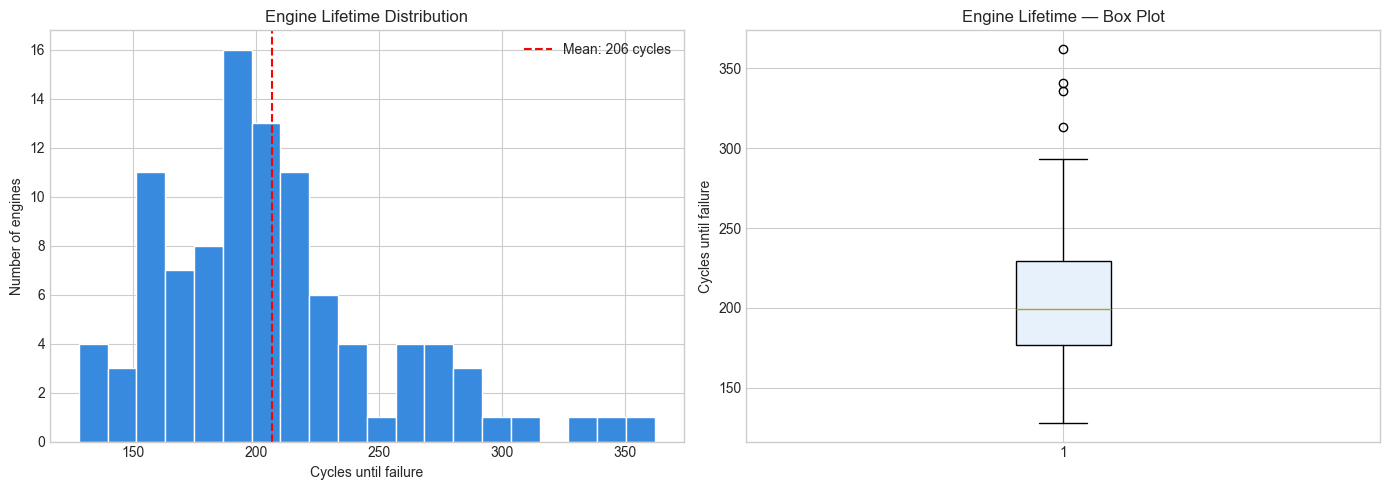

count    100.0
mean     206.3
std       46.3
min      128.0
25%      177.0
50%      199.0
75%      229.2
max      362.0
Name: cycle, dtype: float64


In [3]:
max_cycles = df.groupby('unit_id')['cycle'].max()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(max_cycles, bins=20, color='#378ADD', edgecolor='white')
axes[0].axvline(max_cycles.mean(), color='red', linestyle='--',
                label=f'Mean: {max_cycles.mean():.0f} cycles')
axes[0].set_title('Engine Lifetime Distribution')
axes[0].set_xlabel('Cycles until failure')
axes[0].set_ylabel('Number of engines')
axes[0].legend()

axes[1].boxplot(max_cycles, patch_artist=True,
                boxprops=dict(facecolor='#E6F1FB'))
axes[1].set_title('Engine Lifetime — Box Plot')
axes[1].set_ylabel('Cycles until failure')

plt.tight_layout()
plt.savefig('../results/01_engine_lifetime.png', dpi=150, bbox_inches='tight')
plt.show()
print(max_cycles.describe().round(1))

## 4. RUL Distribution

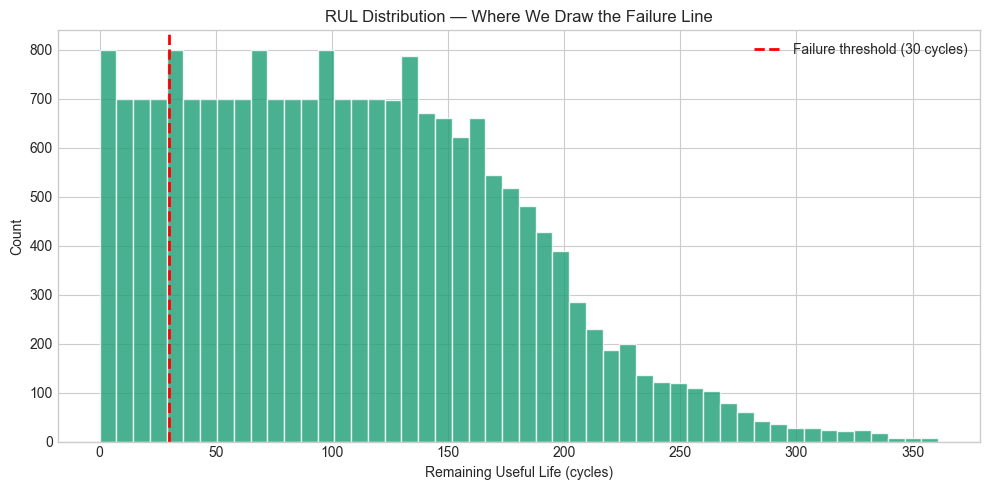

Samples near failure (RUL ≤ 30): 3,100 (15.0%)
Healthy samples: 17,531 (85.0%)

Class imbalance ratio: 5.7:1


In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df['RUL'], bins=50, color='#1D9E75', edgecolor='white', alpha=0.8)
ax.axvline(30, color='red', linestyle='--', linewidth=2,
           label='Failure threshold (30 cycles)')
ax.set_title('RUL Distribution — Where We Draw the Failure Line')
ax.set_xlabel('Remaining Useful Life (cycles)')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.savefig('../results/02_rul_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

near_failure = (df['RUL'] <= 30).sum()
print(f"Samples near failure (RUL ≤ 30): {near_failure:,} ({near_failure/len(df):.1%})")
print(f"Healthy samples: {len(df)-near_failure:,} ({1-near_failure/len(df):.1%})")
print(f"\nClass imbalance ratio: {(len(df)-near_failure)/near_failure:.1f}:1")

## 5. Sensor Degradation Over Time

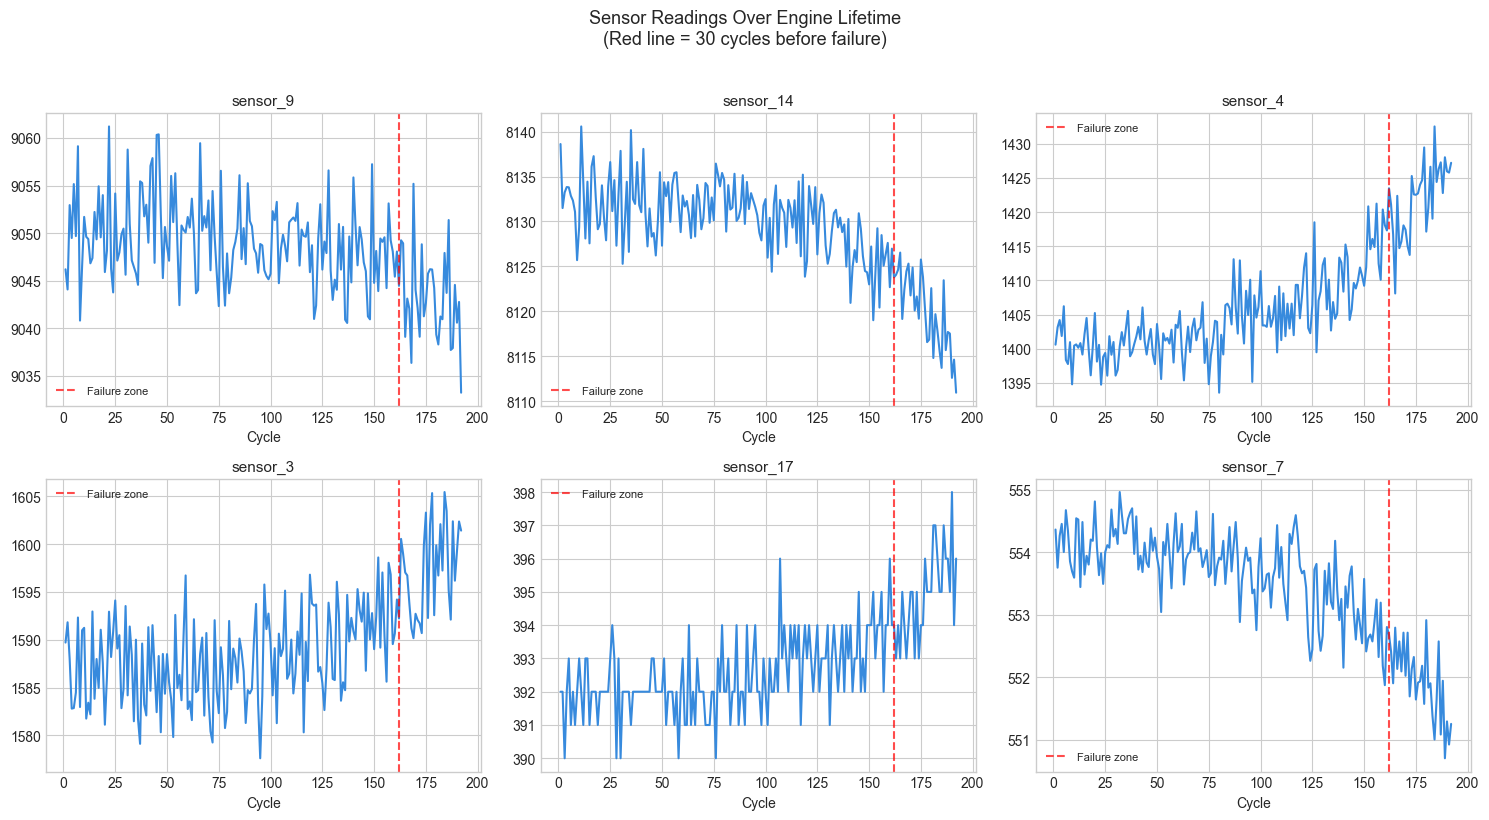

In [5]:
engine_1    = df[df['unit_id'] == 1].sort_values('cycle')
feature_cols = get_feature_columns(df)
top_sensors  = df[feature_cols].var().sort_values(ascending=False).head(6).index

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes      = axes.flatten()

for i, sensor in enumerate(top_sensors):
    axes[i].plot(engine_1['cycle'], engine_1[sensor],
                 color='#378ADD', linewidth=1.5)
    axes[i].axvline(engine_1['cycle'].max() - 30, color='red',
                    linestyle='--', alpha=0.7, label='Failure zone')
    axes[i].set_title(sensor, fontsize=11)
    axes[i].set_xlabel('Cycle')
    axes[i].legend(fontsize=8)

plt.suptitle('Sensor Readings Over Engine Lifetime\n'
             '(Red line = 30 cycles before failure)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../results/03_sensor_degradation.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Correlation Heatmap

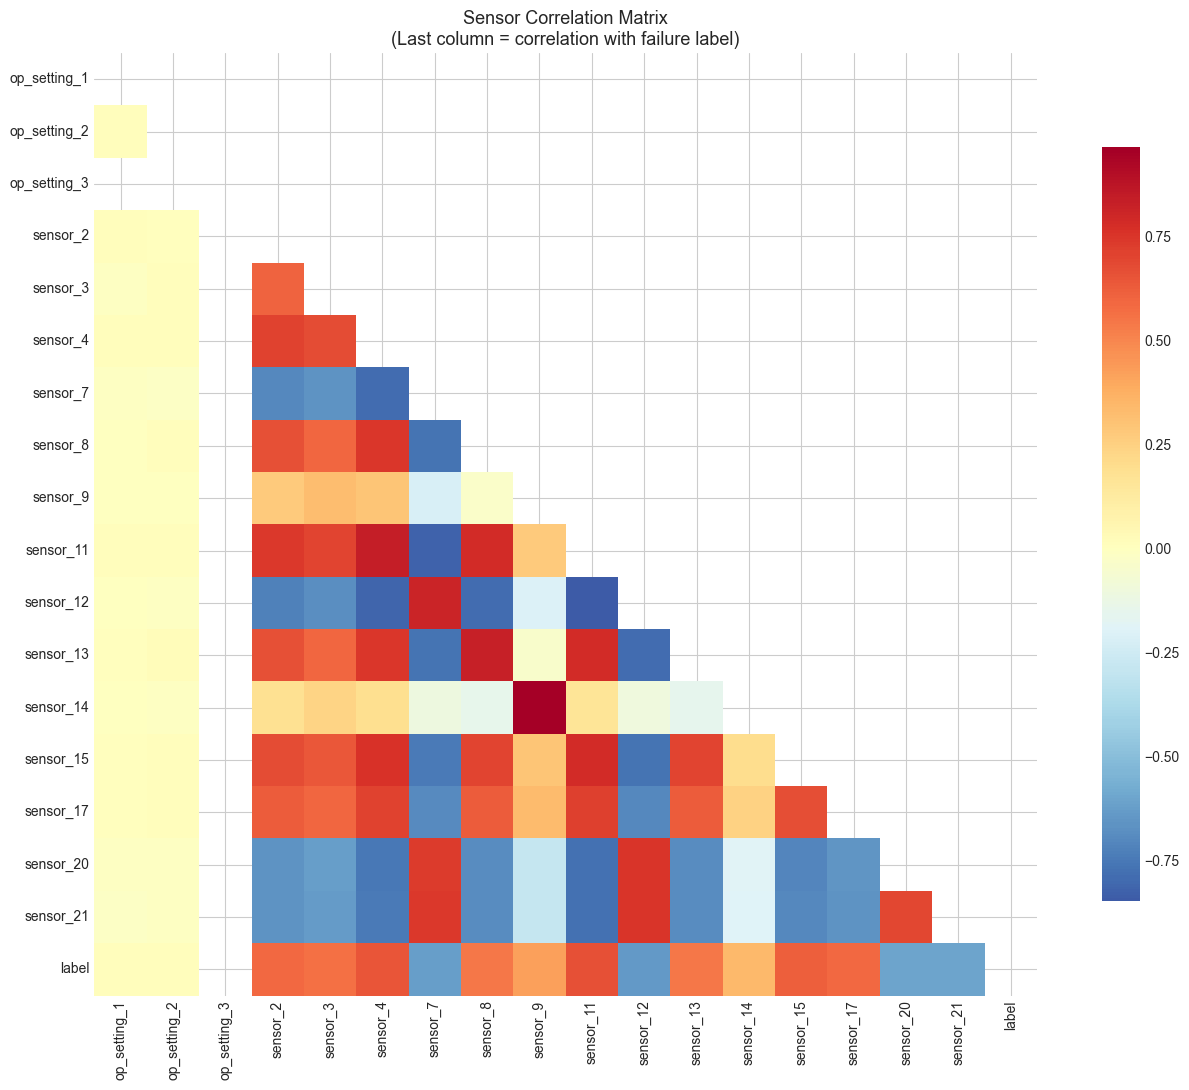


Top sensors correlated with failure:
sensor_11    0.666
sensor_4     0.648
sensor_12    0.640
sensor_7     0.626
sensor_15    0.619
sensor_21    0.606
sensor_20    0.600
sensor_17    0.583
Name: label, dtype: float64


In [6]:
feature_cols = get_feature_columns(df)
corr         = df[feature_cols + ['label']].corr()

plt.figure(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=False, cmap='RdYlBu_r',
            center=0, square=True, cbar_kws={'shrink': 0.8})
plt.title('Sensor Correlation Matrix\n'
          '(Last column = correlation with failure label)', fontsize=13)
plt.tight_layout()
plt.savefig('../results/04_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop sensors correlated with failure:")
print(corr['label'].drop('label').abs()
      .sort_values(ascending=False).head(8).round(3))

## 7. Class Imbalance

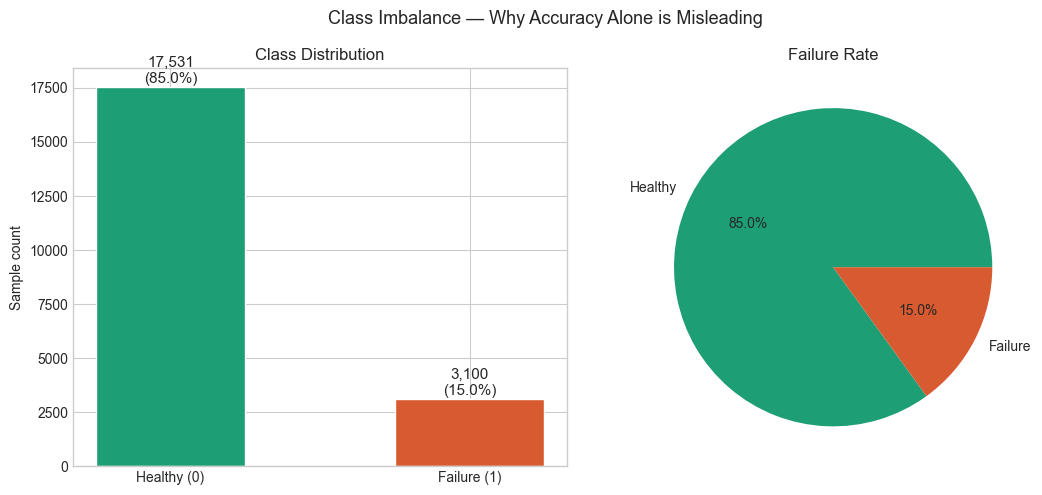


Implication: A model predicting 'always healthy' gets 72.7% accuracy.
This is why we also measure AUC-ROC and PR-AUC — they handle imbalance.


In [7]:
counts = df['label'].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

axes[0].bar(['Healthy (0)', 'Failure (1)'], counts.values,
            color=['#1D9E75', '#D85A30'], edgecolor='white', width=0.5)
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Sample count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 200, f'{v:,}\n({v/len(df):.1%})',
                 ha='center', fontsize=11)

axes[1].pie(counts.values, labels=['Healthy', 'Failure'],
            colors=['#1D9E75', '#D85A30'], autopct='%1.1f%%')
axes[1].set_title('Failure Rate')

plt.suptitle('Class Imbalance — Why Accuracy Alone is Misleading', fontsize=13)
plt.tight_layout()
plt.savefig('../results/05_class_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nImplication: A model predicting 'always healthy' gets 72.7% accuracy.")
print("This is why we also measure AUC-ROC and PR-AUC — they handle imbalance.")

## 8. EDA SUmmary

In [11]:
print("""

             EDA KEY FINDINGS — FD001                   
                                                      
Dataset size:    20,631 rows, 100 engines                 
Failure rate:    ~27% of samples near failure           
Engine lifetime: mean ~206 cycles                       
Features used:   14 sensors (7 dropped, near-zero var)  
                                                          
  Key findings:                                           
  1. Sensors 2,3,4,11,15 show clear degradation pattern  
  2. High inter-sensor correlation — CNN can exploit this 
  3. 27% failure rate — class imbalance present           
     → use AUC-ROC and PR-AUC, not just accuracy          
  4. Failure signal strongest in last 30 cycles           
     → justifies 30-step sliding window choice            
                                                          
  → Findings justify 1D CNN as primary architecture       
  → Sequence length 30 captures the failure signal        

""")



             EDA KEY FINDINGS — FD001                   
                                                      
Dataset size:    20,631 rows, 100 engines                 
Failure rate:    ~27% of samples near failure           
Engine lifetime: mean ~206 cycles                       
Features used:   14 sensors (7 dropped, near-zero var)  
                                                          
  Key findings:                                           
  1. Sensors 2,3,4,11,15 show clear degradation pattern  
  2. High inter-sensor correlation — CNN can exploit this 
  3. 27% failure rate — class imbalance present           
     → use AUC-ROC and PR-AUC, not just accuracy          
  4. Failure signal strongest in last 30 cycles           
     → justifies 30-step sliding window choice            
                                                          
  → Findings justify 1D CNN as primary architecture       
  → Sequence length 30 captures the failure signal        


